Let's talk about the goals of this jupyter notebook

* Establish a normalized 0-1 score of roughness for each image for benchmarking
* Compare to plain multimodal LLM normalized output for all images
* Select multiple train-test splits for fine-tuning such a LLM and compare to human rankings on testing subset

ONCE ERROR FROM ABOVE IS NOW ACCEPTABLE

* Download online dataset & Establish a pipeline for taking images from a large data database and feeding them to a LLM for evaluation in the Normalized 0-1 score
* Use resulting scores to train a CNN, KNN, and SVM

## Plan for Goal 1

1. Load the anonymized survey rankings from the JSON file.
2. Treat each survey row as a set of relative rankings, where lower ranks indicate smoother surfaces and higher ranks indicate rougher ones.
3. Aggregate the ranks for each image by computing the mean rank across all survey responses.
4. Convert those mean ranks into a normalized 0-1 roughness score using min-max scaling.
5. Save the resulting table to a CSV file so it can be reused for benchmarking, model training, and later comparison with LLM outputs.


In [21]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Saved 53 image scores to ..\data\normalized_roughness_scores.csv


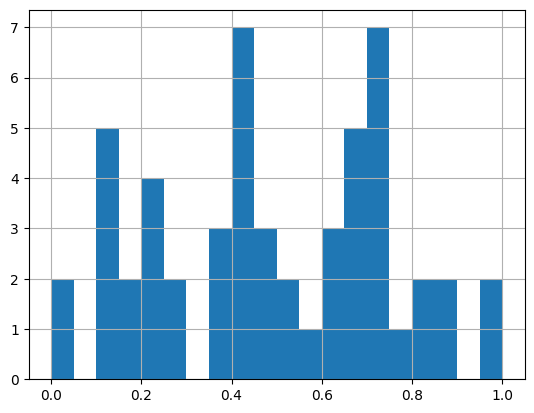

In [22]:
import json
from pathlib import Path

import pandas as pd


def simple_mean_roughness_score():

    survey_path = Path("..") / "data" / "Anonymized_Relative_Roughness_Survey_Results.json"
    output_path = Path("..") / "data" / "normalized_roughness_scores.csv"

    with survey_path.open(encoding="utf-8") as f:
        surveys = json.load(f)

    rank_lists = {}

    for survey in surveys:
        for image_name, rank in survey.items():
            if image_name in {"index", "timestamp", "name", "gender"}:
                continue
            rank_lists.setdefault(image_name, []).append(int(rank))

    score_table = pd.DataFrame(
        {
            "image": list(rank_lists.keys()),
            "rank_count": [len(ranks) for ranks in rank_lists.values()],
            "mean_rank": [sum(ranks) / len(ranks) for ranks in rank_lists.values()],
            "min_rank": [min(ranks) for ranks in rank_lists.values()],
            "max_rank": [max(ranks) for ranks in rank_lists.values()],
        }
    )

    if score_table["mean_rank"].nunique() > 1:
        min_rank = score_table["mean_rank"].min()
        max_rank = score_table["mean_rank"].max()
        score_table["normalized_roughness_score"] = (
            (score_table["mean_rank"] - min_rank) / (max_rank - min_rank)
        )
    else:
        score_table["normalized_roughness_score"] = 0.5

    score_table = score_table.sort_values("normalized_roughness_score", ascending=False).reset_index(drop=True)
    score_table.to_csv(output_path, index=False)

    print(f"Saved {len(score_table)} image scores to {output_path}")
    score_table[["image", "mean_rank", "normalized_roughness_score"]].head(15)
    #create a histogram of the normalized roughness scores 
    score_table["normalized_roughness_score"].hist(bins=20)

simple_mean_roughness_score()


Why the above strategy does not work:

1) It's important to note that the users received each set of 5 images together, not seperately. Thus because of this we cannot directly compare image ratings within on group to image ratings within another group.

Instead the algorithm should kinda create an ordered list of images that we can determine from cross evaluated rankings that it was either ranked higher, lower or undefined. For example, in session one images are ranked [A,B,C,D] and in session two images are ranked [E,D,F,H]: thus we can say that [A,B,C] > [D] > [F,H]; however, we can also know that [A,B,C] = [E], since we don't have a direct comparison.(Why on earth did i make this stupid survey this way, there's definitely a more efficient way to do this.)


Thus going forward a bradley-terry model will be used(https://towardsdatascience.com/learning-from-pairwise-preferences-an-introduction-to-the-bradley-terry-model/)

In [23]:
!pip install choix

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Bradley-Terry Scores: [-1.905 -0.042  0.145  0.858  0.391 -1.318  2.235 -1.064 -0.978 -1.637
  0.604 -1.035 -0.58  -2.936 -0.699  0.358  0.902 -0.872 -0.627 -1.08
  1.484  0.223 -0.909 -0.905 -0.586  0.031  0.152 -0.657  1.209  0.069
  0.095 -0.127 -1.72   1.389 -0.573  0.765  1.632  1.358  1.287  2.302
 -1.185  0.381  0.287 -0.722  1.158  1.458 -2.61  -1.206 -0.327  1.747
  0.677  1.573  1.531]

 proportion of images receiveing scores:  1.0
Final Ranking (Best to Worst): ['Table.jpg', 'Whiteboard.jpg', 'Plastic bag.jpg', 'Stuffed animal fur.jpg', 'Hair(1).jpg', 'Paper(1).jpg', 'Bedsheets_.jpg', 'Fishing line.jpg', 'Lamp fabric.jpg', 'Skin.jpg', 'Paper.jpg', 'Wood.jpg', 'Graphite drawing.jpg', 'Table(1).jpg', 'Skin.png', 'Plastic.jpg', 'Blanket.jpg', 'Stuffed animal fabric.jpg', 'Skin(1).jpg', 'Wall.jpg', 'Towel(1).jpg', 'Table(2).jpg', 'Fabric.jpg', 'Water bottle.jpg', 'Leather chair.jpg', 'Hair.jpg', 'Bed headboard fabric_.jpg', 'Hair(2).jpg', 'Wall(4).jpg', 'Wall(3).jpg', 'Pillowcas

(array([-1.90454229, -0.04199056,  0.14510273,  0.85774571,  0.39146497,
        -1.31782463,  2.23453974, -1.06381347, -0.97801869, -1.63749503,
         0.60361837, -1.0347473 , -0.57989904, -2.93645454, -0.69925482,
         0.35773276,  0.90174695, -0.87182494, -0.62722604, -1.08019112,
         1.48435759,  0.22295685, -0.90866198, -0.90463918, -0.58555401,
         0.03096949,  0.15181224, -0.65672762,  1.20882562,  0.06884293,
         0.09472411, -0.12745625, -1.72040796,  1.38914434, -0.57291443,
         0.76538115,  1.63225431,  1.35801966,  1.28724996,  2.30168837,
        -1.18523062,  0.38061551,  0.28727205, -0.72222772,  1.15824982,
         1.45831167, -2.6099421 , -1.20583714, -0.32708725,  1.74650705,
         0.67719649,  1.57300355,  1.53063474]),
 {'Bark.jpg': 0,
  'Wall(4).jpg': 1,
  'Leather chair.jpg': 2,
  'Skin.png': 3,
  'Skin(1).jpg': 4,
  'Clay sculpture_.jpg': 5,
  'Whiteboard.jpg': 6,
  'Wooden sign.jpg': 7,
  'Rock.jpg': 8,
  'Wall(5).jpg': 9,
  'Stuffe

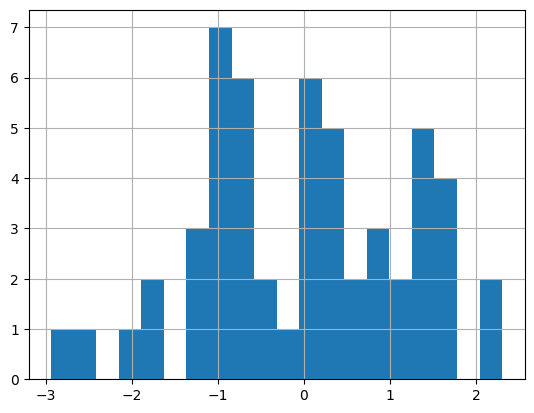

In [24]:
import choix
import numpy as np
def BT_scores_from_surveyJSON(data_path:Path):
    #load survey code
    data_path = Path("..") / "data" / "Anonymized_Relative_Roughness_Survey_Results.json"
    with data_path.open(encoding="utf-8") as f:
        surveys = json.load(f)


    #Develop img2numID for code later on
    img2numID = {}
    i : int = 0
    for survey in surveys:
        for image_name, rank in survey.items():
            if image_name in {"index", "timestamp", "name", "gender"}:
                continue
            img2numID.setdefault(image_name, len(img2numID))


    #which beat which 
    comp_data = []

    #Iterate through the surveys and in each instance organize like this:
    # Find number 1, number 1 lost to all other numbers so it should be assigned 4 loss tuplets, number 2 is assigned 3 loss tuplets, and there it goes further and further.


    for survey in surveys:
        survey.pop("index", None)
        #invert each individual survey instance
        inverted_dict = {val: key for key, val in survey.items()}
        for rank in range(1, len(inverted_dict) + 1):
            winner = inverted_dict[rank]
            for loser_rank in range(rank + 1, len(inverted_dict) + 1):
                loser = inverted_dict[loser_rank]
                comp_data.append((img2numID[winner], img2numID[loser]))
    comp_data

    #Get Bradley-Terry Scores for each image 
    bt_scores = choix.ilsr_pairwise(len(img2numID), comp_data, alpha=0.01)
    print("Bradley-Terry Scores:", np.round(bt_scores, 3))
    print("\n proportion of images receiveing scores: ", len(bt_scores) / len(img2numID))
    #plot histogram of BT scores
    bt_score_table = pd.DataFrame(bt_scores, index=img2numID.keys(), columns=["bt_score"])
    bt_score_table["bt_score"].hist(bins=20)

    #get BT ranked indicies
    bt_ranked_indices = np.argsort(bt_scores)[::-1]#Note that this has the encoded version of the image names
    ID2img = {v: k for k, v in img2numID.items()}
    ranked_img_names = [ID2img[i] for i in bt_ranked_indices]

    print("Final Ranking (Best to Worst):", ranked_img_names)

    return bt_scores, img2numID, bt_ranked_indices 

survey_path = Path("..") / "data" / "Anonymized_Relative_Roughness_Survey_Results.json"
BT_scores_from_surveyJSON(survey_path)




Ok so, now comes the second part where I take data from a multimodal LLM, get it's BT scores and in the end we'll have a nice lil figure with the 3 buckets for each of the different categories(least rough, mid rough, most rough), and then we'll move from there into developing the overall syntethic dataset.

 ### Part II
 

In [25]:
!pip install google-genai

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
!pip install dotenv

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import os
from dotenv import load_dotenv

load_dotenv() # Loads the variables from .env

api_key = os.getenv("GOOGLE_API_KEY")

In [28]:
from google import genai

def basic_api_test():
    client_test = genai.Client(api_key=api_key)
    interaction = client_test.models.generate_content(
        model="gemini-3.6-flash",
        contents="Explain how AI works in a few words"
    )
    print(interaction.text)

    print(f"Prompt Tokens: {interaction.usage_metadata.prompt_token_count}")
    print(f"Output Tokens: {interaction.usage_metadata.candidates_token_count}")
    print(f"Total Tokens: {interaction.usage_metadata.total_token_count}")
basic_api_test()

AI works by **finding patterns in vast amounts of data** and using those patterns to **predict answers, solve problems, or create content.** 

In short: **Data in $\rightarrow$ Pattern learned $\rightarrow$ Smart output out.**
Prompt Tokens: 9
Output Tokens: 48
Total Tokens: 553


In [29]:
import base64
import mimetypes
from google import genai
from google.genai import types

client = genai.Client(api_key=api_key)

def prompt_image_gemini(image_paths, prompt):
    parts = [types.Part.from_text(text=prompt)]

    for img in image_paths:
        mime_type, _ = mimetypes.guess_type(str(img))
        with open(img, "rb") as f:
            image_bytes = f.read()
        parts.append(types.Part.from_bytes(
            data=image_bytes,
            mime_type=mime_type or "image/jpeg"
        ))

    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=parts,
        config=types.GenerateContentConfig(
            temperature=0.1,
            response_mime_type="application/json",
            response_schema=list[str]
        )
    )


    print(f"Prompt Tokens: {response.usage_metadata.prompt_token_count}")
    print(f"Output Tokens: {response.usage_metadata.candidates_token_count}")
    print(f"Total Tokens: {response.usage_metadata.total_token_count}")
    return response.text


prompt_image_gemini(image_paths=[Path("..") / "blue_printer_paper.png"], prompt="Provide a brief explanation of what you see here?")



Prompt Tokens: 1113
Output Tokens: 20
Total Tokens: 1395


'["A solid, uniform light blue background with a subtle paper-like or fabric-like texture."]'

In [33]:
def rank_images_gemini(image_paths, labels=None):
    labels = labels or [chr(65 + i) for i in range(len(image_paths))]

    parts = [types.Part.from_text(text=(
        "You will see several texture images, each preceded by its label. "
        "Rank them from roughest to smoothest based on visual texture. "
        "Respond ONLY with a JSON array of labels in order from roughest "
        "to smoothest, e.g. [\"C\", \"A\", \"E\", \"B\", \"D\"]. No other text."
    ))]

    for label, path in zip(labels, image_paths):
        mime_type, _ = mimetypes.guess_type(str(path))
        parts.append(types.Part.from_text(text=f"Image {label}:"))
        with open(path, "rb") as f:
            image_bytes = f.read()
        parts.append(types.Part.from_bytes(data=image_bytes, mime_type=mime_type or "image/jpeg"))

    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=parts,
        config=types.GenerateContentConfig(
                    temperature=0.1,
                    response_mime_type="application/json",
                    response_schema=list[str]
                )
    )

    print(f"Prompt Tokens: {response.usage_metadata.prompt_token_count}")
    print(f"Output Tokens: {response.usage_metadata.candidates_token_count}")
    print(f"Total Tokens: {response.usage_metadata.total_token_count}")
    return response.text

#Example prompt
output = rank_images_gemini(image_paths=[Path("..") / "blue_printer_paper.png", Path("..") / "closeup_sandpaper.jpg"], labels=["YS", "UV"])
test_json =json.loads(output)
test_json


Prompt Tokens: 2265
Output Tokens: 13
Total Tokens: 2427


['UV', 'YS']

In [34]:
#Generating Random-seeming IDs for  LLM to ensure no interference either from the original names, or from the order of the images(i.e. AI having a preference to put A as more rough)
%pip install cryptography #deprecated, now works on secrets
from cryptography.fernet import Fernet
import secrets

def get_key(): # deprecated
    # Generate a key for encryption
    key = Fernet.generate_key()
    return key

def encode_filename(filename,key=None):
    return secrets.token_hex(4)

    '''
    fernet = Fernet(key)
    encoded_filename = fernet.encrypt(filename.encode()).decode()
    return encoded_filename
    '''

def decode_filename(encoded_filename,key):
    return 

    '''
    inv_fernet = Fernet(key)
    decoded_filename = inv_fernet.decrypt(encoded_filename.encode()).decode()
    return decoded_filename
    '''


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#deprecated,': Expected package name at the start of dependency specifier
    #deprecated,
    ^


In [ ]:
#Method loads original survey results, encodes the image names and sends the previous groups of 5 to the LLM to rank them, then stores the index, fernet_key, and the rankings of the 5 images in a dictionary which is then sent to a JSON
import json
import random
from pathlib import Path


def eval_LLM_survey(og_results_path, output_path):
    with open(og_results_path, "r", encoding="utf-8") as f:
        surveys = json.load(f)

    results = []
    ranked_images = []
    for survey in surveys:
        filenames = [k for k in survey if k != "index"]

        tokens = set()
        while len(tokens) < len(filenames):
            tokens.add(encode_filename(None))
        tokens = list(tokens)

        encoded_survey = dict(zip(tokens, filenames))
        result = {"index": survey["index"], "survey": encoded_survey}

        image_paths = [Path("..") / "data" / "RRS_Sample_Images" / name for name in encoded_survey.values()]
        fernet_tokens = list(encoded_survey.keys())

        paired = list(zip(image_paths, fernet_tokens))
        random.shuffle(paired)
        shuffled_paths, shuffled_tokens = zip(*paired)

        labels = [chr(65 + i) for i in range(len(shuffled_paths))]
        label_to_token = dict(zip(labels, shuffled_tokens))

        raw_response = rank_images_gemini(list(shuffled_paths), labels)

        try:
            ranked_labels = json.loads(raw_response)
        except json.JSONDecodeError:
            cleaned = raw_response.strip().strip("`").replace("json\n", "", 1).strip()
            ranked_labels = json.loads(cleaned)

        result["ranked_labels"] = [label_to_token[l] for l in ranked_labels]

        ranked_filenames = [encoded_survey[token] for token in result["ranked_labels"]]
        ranked_entry = {"index": survey["index"]}
        for rank, filename in enumerate(ranked_filenames, start=1):
            ranked_entry[filename] = rank
        ranked_images.append(ranked_entry)

        results.append(result)
        print(result)
        

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump({"results": results, "ranked_images": ranked_images}, f, indent=2)

    print(f"Wrote {len(results)} ranked survey result(s) to {output_path}")
    
eval_LLM_survey(
    Path("..") / "data" / "Anonymized_Relative_Roughness_Survey_Results.json",
    Path("..") / "data" / "LLM_Ranked_Survey_Results.json"
)

Prompt Tokens: 5491
Output Tokens: 15
Total Tokens: 6092
{'index': 0, 'survey': {'f722ef3a': 'Bark.jpg', 'e9f12852': 'Wall(4).jpg', '76580995': 'Leather chair.jpg', 'b6ec2851': 'Skin.png', '372ac5c3': 'Skin(1).jpg'}, 'ranked_labels': ['f722ef3a', 'e9f12852', '76580995', 'b6ec2851', '372ac5c3']}
Wrote 1 ranked survey result(s) to ..\data\LLM_Ranked_Survey_Results.json
